In [1]:
from Forecast.SimpleTransformerForecast import SimpleTransformerForecast
from Forecast.PatchTransformerForecast import PatchTransformerForecast, PatchTransformerForecast2
from Dataloaders.DataloaderECG import ECGDataset
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import torch
import numpy as np
import torch.nn.functional as F
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import DataLoader
import os
import time
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Function to train the model
def train_loop(model, train, val, optimizer, scheduler=None, patience=5, epochs=100, lossf=F.mse_loss):
    """_Training loop for the model_

    Args:
        model: model to train
        optimizer: pytorch optimizer, for example torch.optim.Adam
        train: training data
        val: validation data
        epochs: number of epochs

    Returns:
        _type_: training history, a dictionary with the training and validation loss for each epoch
    """
    def epoch_loss(dataset):
        data_loss = 0.0
        for i, (lookback_data, horizon_data) in enumerate(dataset):
            inputs = lookback_data.to('cuda')
            y = horizon_data.to('cuda')
            outputs = model(inputs).squeeze()
            loss = lossf(y, outputs)
            data_loss += loss.item()  
        return data_loss / (i + 1)
    
    def early_stopping(val_loss, patience=5):
        if len(val_loss) > patience:
            if val_loss[-1] > np.mean(val_loss[-(patience+1):-1]):
                return True
    
    hist_loss = {'train': [], 'val': []}
    pbar = tqdm(range(epochs))
    for epoch in pbar:  # loop for all the epochs
        for i, (lookback_data, horizon_data) in enumerate(train):
            # take the data and upload it to the GPU
            inputs = lookback_data.to('cuda')
            y = horizon_data.to('cuda')

            # Reset the gradients
            optimizer.zero_grad()

            # Apply the data to the model
            outputs = model(inputs).squeeze()
            # Calculate the loss
            loss = lossf(y, outputs)

            # Make the backward pass
            loss.backward()
            optimizer.step()

        if scheduler is not None:
            scheduler.step()

        # Calculate the loss in the training and validation sets
        with torch.no_grad():
            hist_loss['train'].append(epoch_loss(train))
            hist_loss['val'].append(epoch_loss(val))

        # Show the loss in the training and validation sets
        pbar.set_postfix({'train': hist_loss['train'][-1], 'val': hist_loss['val'][-1], 'lr': optimizer.param_groups[0]['lr']})

        # If the loss in the validation set does not decrease, stop the training
        if early_stopping(hist_loss['val'], patience):
            break
            
    return hist_loss 

In [98]:
def plot_prediction(model, data, channel=0):
    X, y = data

    pred = model(torch.tensor(X).unsqueeze(0).to(
        'cuda')).squeeze().cpu().detach().numpy()

    plt.figure(figsize=(12, 6))
    ax = plt.subplot(1, 2, 1)
    plt.plot(X[channel], label='lookback')
    mx, mn = np.max(X[channel]), np.min(X[channel])
    plt.legend()
    ax = plt.subplot(1, 2, 2)
    plt.plot(y, label='true')
    plt.plot(pred, label='pred')
    #plt.ylim(mn , mx )
    plt.legend()

In [113]:
lookback = 100
horizon = 25
batch_size = 2048
stride = 10
norm = "zscore"
norm_all = False
samples = (2500, 200, 200)
channel = 0

In [114]:
train = ECGDataset(dir='../Preprocess/PTBXL',
                   dataset='train',
                   nsamples=samples[0],
                   channel=channel,
                   norm=norm,
                   norm_all=norm_all,
                   lookback=lookback,
                   horizon=horizon,
                   stride=stride)
val = ECGDataset(dir='../Preprocess/PTBXL',
                 dataset='validation',
                 nsamples=samples[1],
                 channel=channel,
                 norm=norm,
                 norm_all=norm_all,
                 lookback=lookback,
                 horizon=horizon,
                 stride=stride)
test = ECGDataset(dir='../Preprocess/PTBXL',
                   dataset='test',
                   nsamples=samples[2],
                   channel=channel,
                   norm=norm,
                   norm_all=norm_all,
                   lookback=lookback,
                   horizon=horizon,
                   stride=stride)
train = DataLoader(train, batch_size=batch_size, shuffle=True)
val = DataLoader(val, batch_size=batch_size, shuffle=False)
test = DataLoader(test, batch_size=batch_size, shuffle=False)

Loading data from ../Preprocess/PTBXL
train
X_train shape is (220000, 8, 100)
y_train shape is (220000, 25)
NORM=zscore
Loading data from ../Preprocess/PTBXL
validation
X_train shape is (17600, 8, 100)
y_train shape is (17600, 25)
NORM=zscore
Loading data from ../Preprocess/PTBXL
test
X_train shape is (17600, 8, 100)
y_train shape is (17600, 25)
NORM=zscore


In [115]:
# model = SimpleTransformerForecast(lookback=lookback,
#                                   horizon=horizon,
#                                   input_dim=8,
#                                   target_dim=1,
#                                   d_model=16,
#                                   n_heads=2,
#                                   num_layers=6, dropout=0).to('cuda')
# model.compile()

In [116]:
# model = PatchTransformerForecast(lookback=lookback,
#                                 horizon=horizon,
#                                 input_dim=8,
#                                 target_dim=1,
#                                 d_model=64,
#                                 n_heads=8,
#                                 num_layers=2, dropout=0, patch_len=10).to('cuda')

In [127]:
model = PatchTransformerForecast2(lookback=lookback,
                                  horizon=horizon,
                                  input_dim=8,
                                  target_dim=1,
                                  d_model=64,
                                  n_heads=8,
                                  num_layers=2,
                                  norm_first=True,
                                  dropout=0,
                                  patch_len=10,
                                  layer_norm_eps=1e-5,
                                  bias=True,
                                  swiglu=True,
                                  rmsnorm=True,
                                  trans_norm=True,
                                  device='cuda').to('cuda')
model.compile()

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = StepLR(optimizer, step_size=01, gamma=0.90)

In [129]:
# # Testing the model with random input
# random_input = torch.randn(32, 8, 120).to('cuda')
# model.to('cuda')
# model(random_input).shape

In [130]:
hist_loss = train_loop(model, train, val, optimizer, scheduler, epochs=1000, patience=100)

  0%|          | 0/1000 [00:00<?, ?it/s]

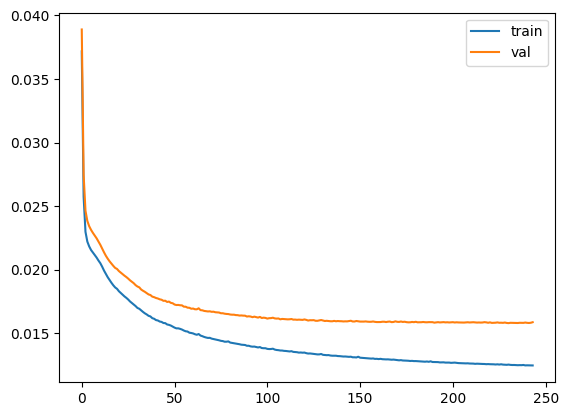

In [131]:
plt.plot(hist_loss['train'], label='train')
plt.plot(hist_loss['val'], label='val')
plt.legend()


In [132]:
print(scheduler.get_last_lr())

[7.976644307687257e-06]


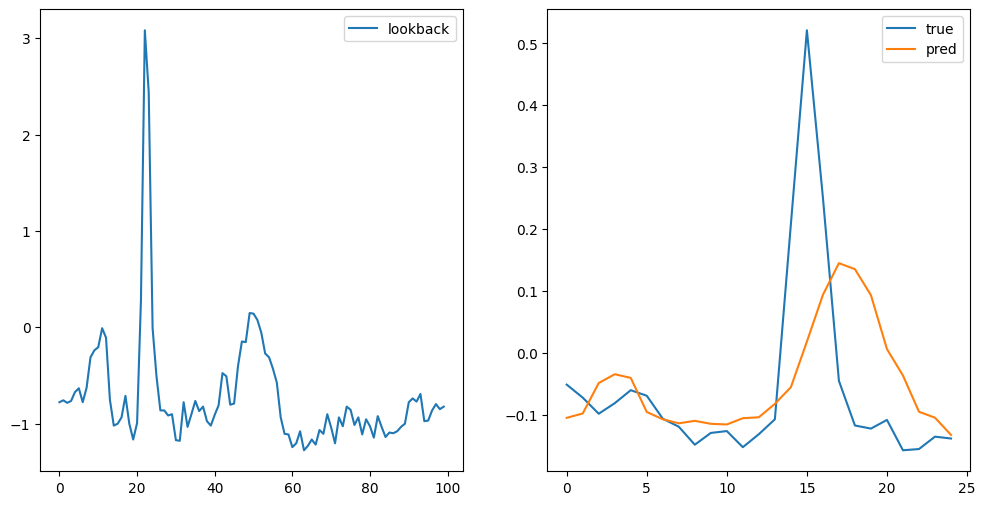

In [133]:
plot_prediction(model, train.dataset[0])

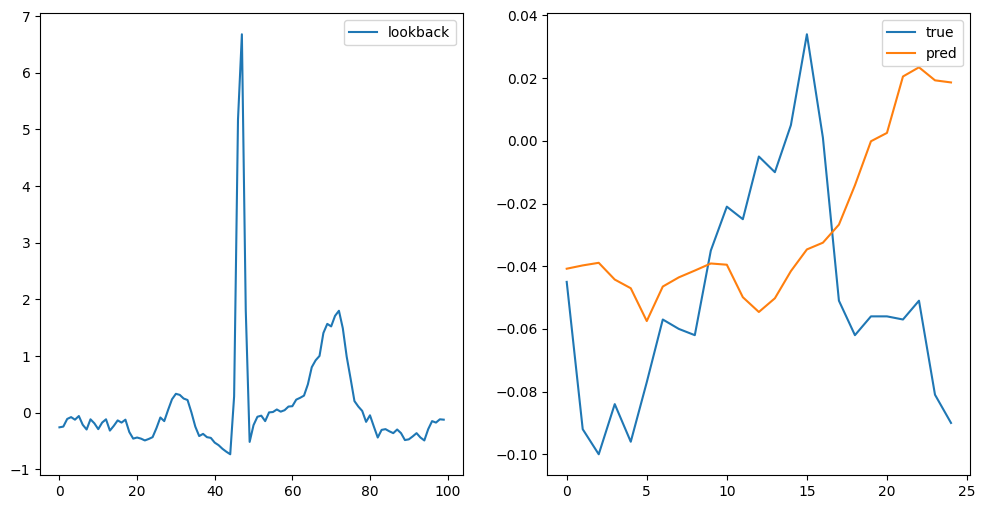

In [134]:
plot_prediction(model, val.dataset[0])

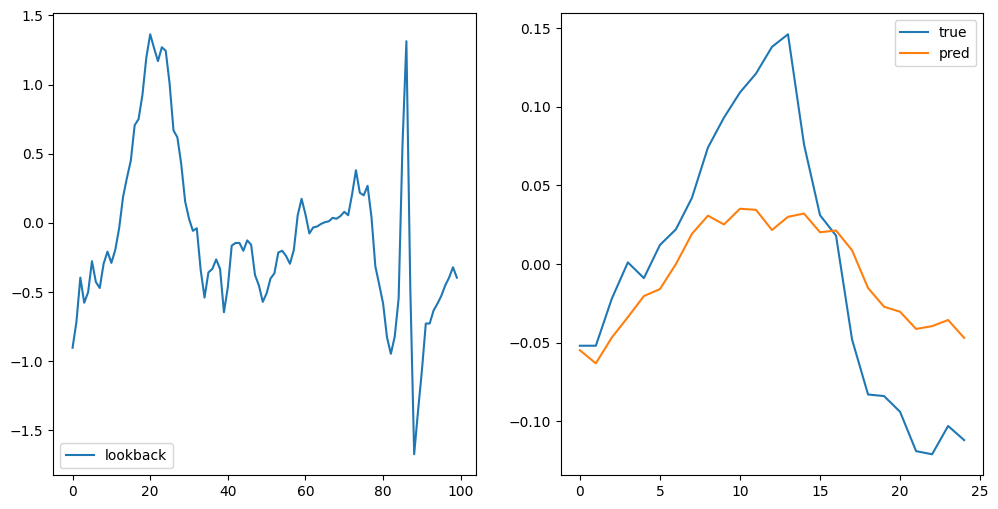

In [135]:
plot_prediction(model, test.dataset[0])

In [136]:
def dataset_loss(dataset):
    data_loss = 0.0
    for i, (lookback_data, horizon_data) in enumerate(dataset):
        inputs = lookback_data.to('cuda')
        y = horizon_data.to('cuda')
        outputs = model(inputs).squeeze()
        loss = F.mse_loss(y, outputs)
        data_loss += loss.item()
    return data_loss / (i + 1)
print('Train loss:', dataset_loss(train))
print('Val loss:', dataset_loss(val))
print('Test loss:', dataset_loss(test))

Train loss: 0.01248901525374364
Val loss: 0.015883702370855544
Test loss: 0.015561296190652583
